In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
teams = pd.read_csv('teams.csv')

In [3]:
teams.head()

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [4]:
teams.shape

(2144, 11)

In [5]:
teams.isnull().sum()

team               0
country            0
year               0
events             0
athletes           0
age                0
height             0
weight             0
medals             0
prev_medals      130
prev_3_medals    130
dtype: int64

In [6]:
teams.describe()

,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
count,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2014.000000,2014.000000
mean,1994.507463,35.724813,73.693097,24.778591,173.900233,69.271595,10.556437,10.248759,9.449901
std,15.384205,49.490270,127.907577,2.808559,5.357367,7.606507,33.028143,31.951920,28.232227
min,1964.000000,1.000000,1.000000,17.000000,151.000000,43.000000,0.000000,0.000000,0.000000
25%,1984.000000,6.000000,7.000000,23.275000,170.500000,64.500000,0.000000,0.000000,0.000000
50%,1996.000000,13.000000,19.000000,24.700000,174.400000,69.400000,0.000000,0.000000,0.300000
75%,2008.000000,44.000000,70.250000,26.100000,177.300000,73.400000,4.000000,4.000000,4.650000
max,2016.000000,270.000000,839.000000,66.000000,193.000000,148.000000,442.000000,442.000000,314.000000


In [7]:
teams = teams[["team", "country", "year", "athletes", "age", "prev_medals", "medals"]]

In [8]:
teams.shape

(2144, 7)

In [9]:
teams.isnull().sum()

team             0
country          0
year             0
athletes         0
age              0
prev_medals    130
medals           0
dtype: int64

In [10]:
teams.describe()

,year,athletes,age,prev_medals,medals
count,2144.000000,2144.000000,2144.000000,2014.000000,2144.000000
mean,1994.507463,73.693097,24.778591,10.248759,10.556437
std,15.384205,127.907577,2.808559,31.951920,33.028143
min,1964.000000,1.000000,17.000000,0.000000,0.000000
25%,1984.000000,7.000000,23.275000,0.000000,0.000000
50%,1996.000000,19.000000,24.700000,0.000000,0.000000
75%,2008.000000,70.250000,26.100000,4.000000,4.000000
max,2016.000000,839.000000,66.000000,442.000000,442.000000


In [11]:
teams.corr(numeric_only=True)

,year,athletes,age,prev_medals,medals
year,1.000000,-0.056957,-0.012179,-0.017917,-0.021603
athletes,-0.056957,1.000000,0.036358,0.810576,0.840817
age,-0.012179,0.036358,1.000000,0.032596,0.025096
prev_medals,-0.017917,0.810576,0.032596,1.000000,0.920048
medals,-0.021603,0.840817,0.025096,0.920048,1.000000


In [12]:
teams.corr(numeric_only=True)["medals"][:-1]

year          -0.021603
athletes       0.840817
age            0.025096
prev_medals    0.920048
Name: medals, dtype: float64

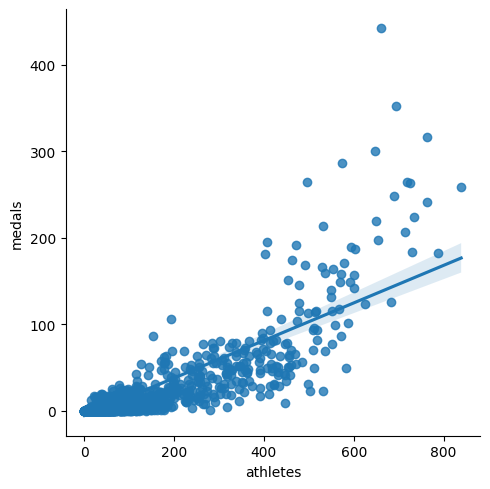

In [13]:
sns.lmplot(x="athletes", y="medals", data=teams)

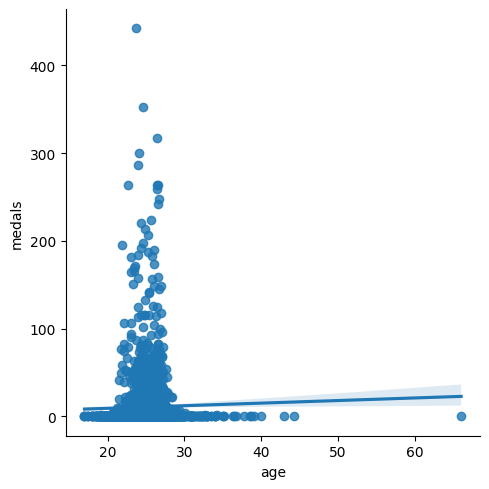

In [14]:
sns.lmplot(x="age", y="medals", data=teams)

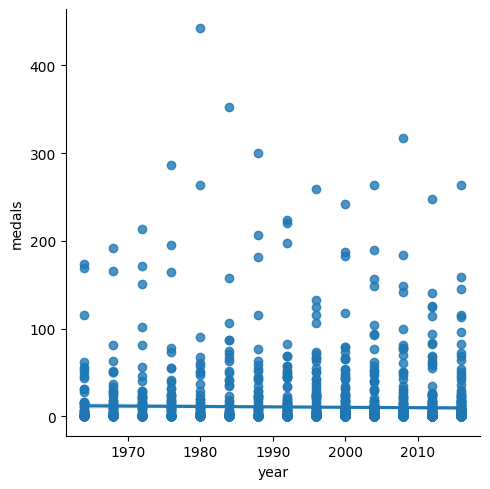

In [15]:
sns.lmplot(x="year", y="medals", data=teams)

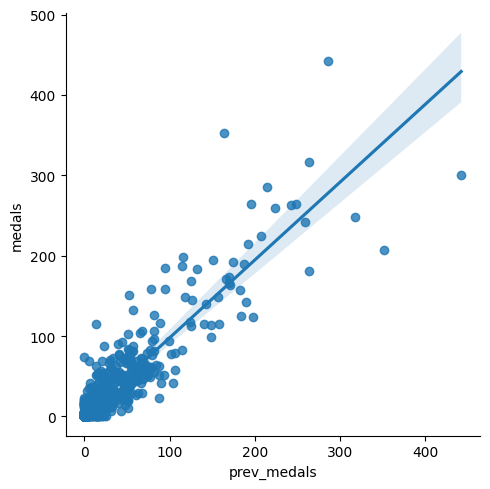

In [16]:
sns.lmplot(x="prev_medals", y="medals", data=teams)

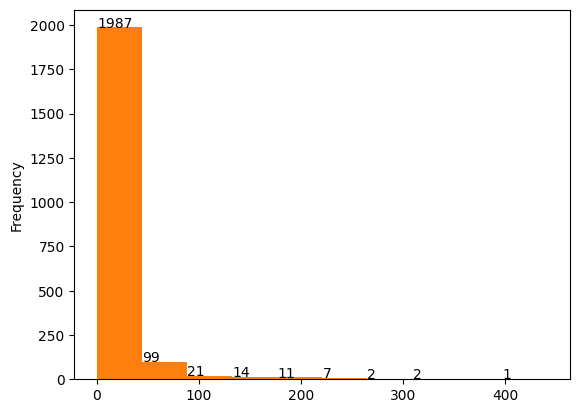

In [17]:
import matplotlib.pyplot as plt

ax = teams["medals"].plot.hist(bins=10)

# Get counts and bin edges
counts, bins = ax.hist(teams["medals"], bins=10)[0:2]

# Add text (counts) on each bar
for count, x in zip(counts, bins):
    if count > 0:
        plt.text(x, count, int(count))

plt.show()

In [18]:
teams.isnull().any(axis=0)

team           False
country        False
year           False
athletes       False
age            False
prev_medals     True
medals         False
dtype: bool

In [19]:
teams[teams.isnull().any(axis=1)].shape

(130, 7)

In [20]:
teams.dropna(inplace=True)

In [21]:
teams[teams.isnull().any(axis=1)].shape

(0, 7)

In [22]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [23]:
train.shape

(1609, 7)

In [24]:
test.shape

(405, 7)

In [25]:
from sklearn.linear_model import LinearRegression
LR = LinearRegression()

In [26]:
predictors = ["athletes", "prev_medals"]
target = ["medals"]

In [27]:
LR.fit(train[predictors], train[target])

LinearRegression()

In [28]:
predictions = LR.predict(test[predictors])

In [29]:
predictions[:5]

array([[-0.96122125],
       [-1.17633261],
       [-1.42503158],
       [-1.71184673],
       [ 2.15562926]])

In [30]:
test.loc[:, "predictions"] = predictions

In [31]:
test.head()

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,-0.961221
7,AFG,Afghanistan,2016,3,24.7,1.0,0,-1.176333
24,ALB,Albania,2012,10,25.7,0.0,0,-1.425032
25,ALB,Albania,2016,6,23.7,0.0,0,-1.711847
37,ALG,Algeria,2012,39,24.8,2.0,1,2.155629


In [32]:
test.loc[test["predictions"] < 0, "predictions"] = 0

In [33]:
(test["predictions"] < 0).any(axis=0)

False

In [34]:
test["predictions"] = test.predictions.round()

In [35]:
test.head()

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0


In [36]:
from sklearn.metrics import mean_absolute_error

error = mean_absolute_error(test.medals, test.predictions)

In [37]:
error

3.2987654320987656

In [38]:
teams.medals.describe()

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [39]:
test[test["team"] == "USA"]

,team,country,year,athletes,age,prev_medals,medals,predictions
2053,USA,United States,2012,689,26.7,317.0,248,285.0
2054,USA,United States,2016,719,26.4,248.0,264,236.0


In [40]:
test[test["team"] == "IND"]

,team,country,year,athletes,age,prev_medals,medals,predictions
907,IND,India,2012,95,26.0,3.0,6,7.0
908,IND,India,2016,130,26.1,6.0,2,12.0


In [41]:
errors = (test.medals - test.predictions).abs()

In [42]:
errors[:5]

6     1.0
7     0.0
24    0.0
25    0.0
37    1.0
dtype: float64

In [43]:
errors_by_team = errors.groupby(test.team).mean()
medals_by_team = test.medals.groupby(test.team).mean()

In [44]:
errors_ratio = errors_by_team / medals_by_team

In [45]:
errors_ratio[:5]

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
dtype: float64

In [46]:
errors_ratio.shape

(204,)

In [47]:
errors_ratio.dropna().shape

(102,)

In [48]:
type(errors_ratio)

pandas.core.series.Series

In [49]:
errors_ratio = errors_ratio[np.isfinite(errors_ratio)]

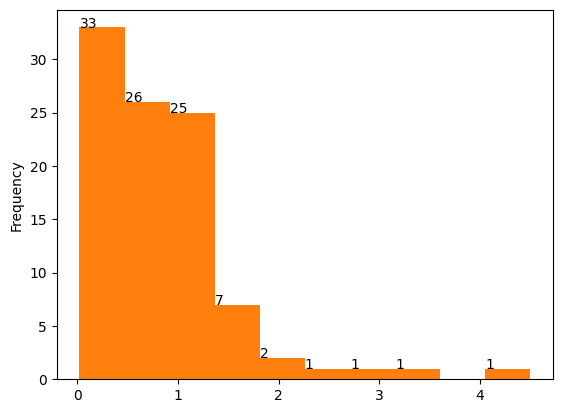

In [50]:
import matplotlib.pyplot as plt

ax = errors_ratio.plot.hist(bins=10)

# Get counts and bin edges
counts, bins = ax.hist(errors_ratio, bins=10)[0:2]

# Add text (counts) on each bar
for count, x in zip(counts, bins):
    if count > 0:
        plt.text(x, count, int(count))

plt.show()

In [51]:
errors_ratio[errors_ratio >= 0.91].shape

(38,)

In [52]:
bins

array([0.02247191, 0.47022472, 0.91797753, 1.36573034, 1.81348315,
       2.26123596, 2.70898876, 3.15674157, 3.60449438, 4.05224719,
       4.5       ])

## My Version of Code

In [89]:
olympics_data = pd.read_csv("teams.csv")

In [90]:
olympics_data.head()

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0


In [91]:
olympics_data.shape

(2144, 11)

In [92]:
# olympics_data = olympics_data[["team", "country", "year", "athletes", "age", "prev_medals", "medals"]]

In [93]:
olympics_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   team           2144 non-null   object 
 1   country        2144 non-null   object 
 2   year           2144 non-null   int64  
 3   events         2144 non-null   int64  
 4   athletes       2144 non-null   int64  
 5   age            2144 non-null   float64
 6   height         2144 non-null   float64
 7   weight         2144 non-null   float64
 8   medals         2144 non-null   int64  
 9   prev_medals    2014 non-null   float64
 10  prev_3_medals  2014 non-null   float64
dtypes: float64(5), int64(4), object(2)
memory usage: 184.4+ KB


In [94]:
olympics_data.describe()

,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
count,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2144.000000,2014.000000,2014.000000
mean,1994.507463,35.724813,73.693097,24.778591,173.900233,69.271595,10.556437,10.248759,9.449901
std,15.384205,49.490270,127.907577,2.808559,5.357367,7.606507,33.028143,31.951920,28.232227
min,1964.000000,1.000000,1.000000,17.000000,151.000000,43.000000,0.000000,0.000000,0.000000
25%,1984.000000,6.000000,7.000000,23.275000,170.500000,64.500000,0.000000,0.000000,0.000000
50%,1996.000000,13.000000,19.000000,24.700000,174.400000,69.400000,0.000000,0.000000,0.300000
75%,2008.000000,44.000000,70.250000,26.100000,177.300000,73.400000,4.000000,4.000000,4.650000
max,2016.000000,270.000000,839.000000,66.000000,193.000000,148.000000,442.000000,442.000000,314.000000


In [95]:
olympics_data.isnull().sum()

team               0
country            0
year               0
events             0
athletes           0
age                0
height             0
weight             0
medals             0
prev_medals      130
prev_3_medals    130
dtype: int64

In [96]:
olympics_data.dropna(inplace=True)

In [97]:
olympics_data.columns

Index(['team', 'country', 'year', 'events', 'athletes', 'age', 'height',
       'weight', 'medals', 'prev_medals', 'prev_3_medals'],
      dtype='object')

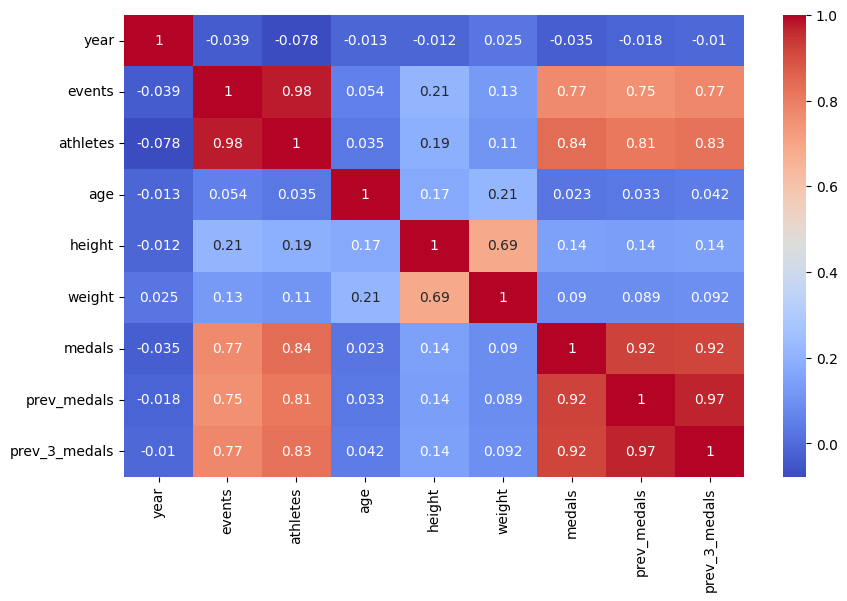

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = olympics_data.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [101]:
corr.medals.sort_values(ascending=True)[:-1]

year            -0.034870
age              0.023231
weight           0.089701
height           0.141946
events           0.770646
athletes         0.839909
prev_3_medals    0.918438
prev_medals      0.920048
Name: medals, dtype: float64

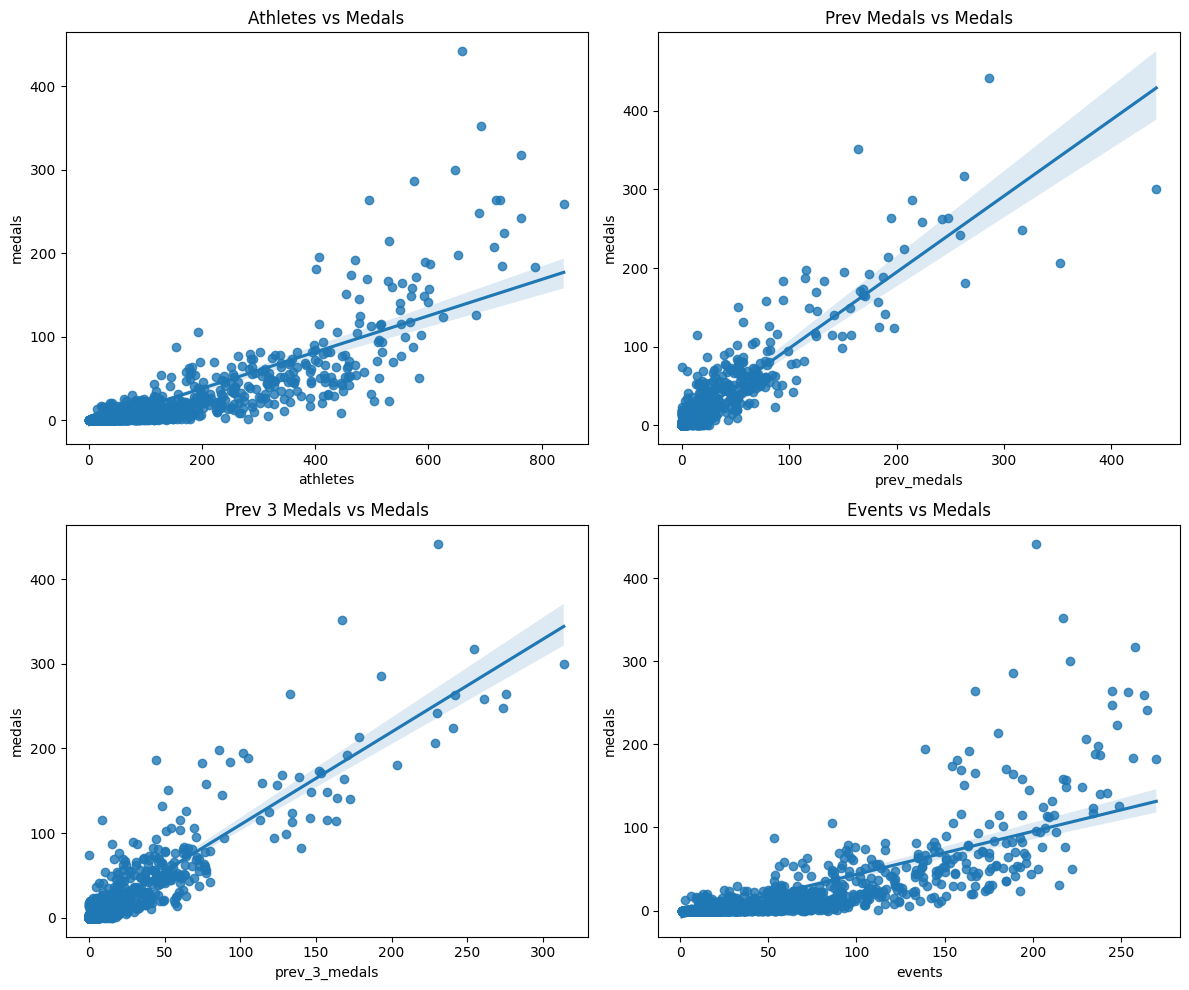

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1
sns.regplot(x="athletes", y="medals", data=olympics_data, ax=axes[0,0])
axes[0,0].set_title("Athletes vs Medals")
# Plot 2
sns.regplot(x="prev_medals", y="medals", data=olympics_data, ax=axes[0,1])
axes[0,1].set_title("Prev Medals vs Medals")
# Plot 3
sns.regplot(x="prev_3_medals", y="medals", data=olympics_data, ax=axes[1,0])
axes[1,0].set_title("Prev 3 Medals vs Medals")
# Plot 4
sns.regplot(x="events", y="medals", data=olympics_data, ax=axes[1,1])
axes[1,1].set_title("Events vs Medals")

plt.tight_layout()
plt.show()

In [122]:
features = [
    "athletes",
    "events",
    "prev_medals",
    "prev_3_medals"
]

In [123]:
train = olympics_data[olympics_data.year < 2012]
test = olympics_data[olympics_data.year >= 2012]

In [124]:
X_train = train[features]
y_train = train.medals

X_test = test[features]
y_test = test.medals

In [125]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1609, 4), (405, 4), (1609,), (405,))

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scalaer", StandardScaler()),
    ("model", LinearRegression()),
])

In [127]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scalaer', StandardScaler()), ('model', LinearRegression())])

In [128]:
preds = pipeline.predict(X_test)

In [131]:
preds[:5]

array([ 0.30676791,  0.97824479, -0.4751498 , -0.18852872, -0.17323717])

In [134]:
preds[preds < 0] = 0

In [137]:
preds = preds.round()

In [138]:
preds[:5]

array([0., 1., 0., 0., 0.])

In [139]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

MAE:  3.4024691358024692
RMSE:  8.138613950608361
R2 Score:  0.9200575292818429


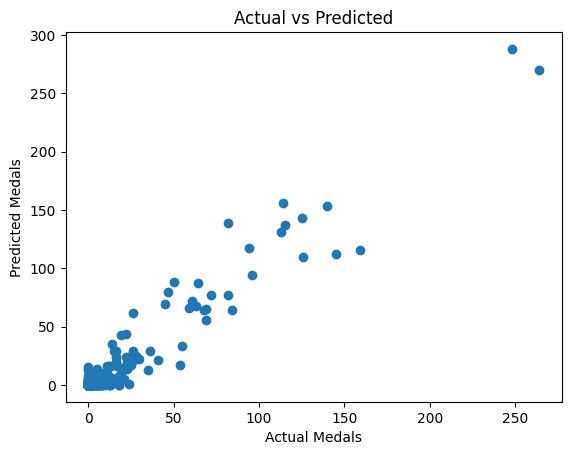

In [140]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)
plt.xlabel("Actual Medals")
plt.ylabel("Predicted Medals")
plt.title("Actual vs Predicted")
plt.show()

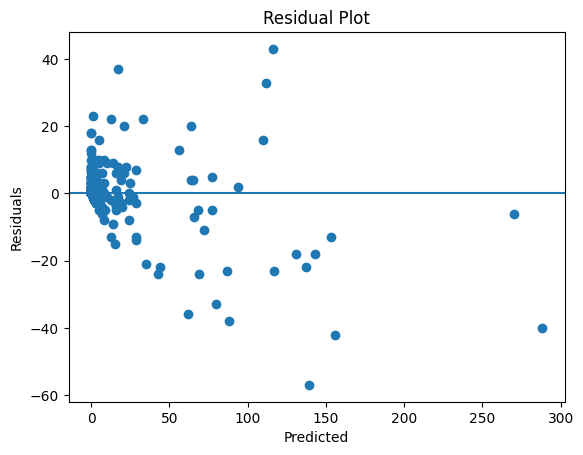

In [142]:
residuals = y_test - preds

plt.scatter(preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [149]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE: ", mae)
print("RMSE: ", rmse)
print("R2 Score: ", r2)

MAE:  3.445652431150275
RMSE:  9.397116338264837
R2 Score:  0.8934224146371892


<Axes: >

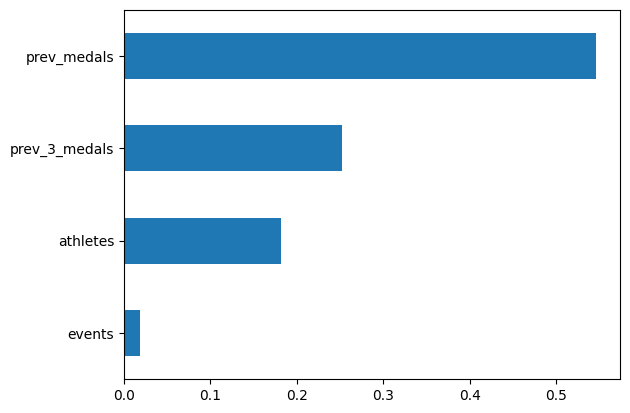

In [150]:
import pandas as pd

importances = model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names)
feat_imp.sort_values().plot(kind="barh")